# Capstone Design Framework

**DS2002 | 2026-03-30 | Lecture**

---

## What is this capstone?

For the next four weeks your team will build a cloud data pipeline. You will take messy raw data, clean it, store it in Google Cloud, analyze it, and present your findings. The domain is **EV charging station analytics** for Charlottesville.

This is not a repeat of the midterm. The midterm was local — pandas, SQLite, API calls, all on your machine. The capstone adds a cloud layer. Your raw data lives in a GCS bucket. Your cleaned data gets uploaded back. You authenticate with a service account. Everything else (the cleaning, the analysis, the charts) you already know how to do.

The cloud part is the new skill. Everything else is reinforcement.

## Why cloud?

Three reasons.

**1. Scale.** Your laptop can handle 27,000 rows. Production datasets have billions. Cloud storage and compute exist because local machines hit limits.

**2. Collaboration.** When data lives in a shared bucket, your whole team can access it without emailing CSVs around. One source of truth.

**3. It is how the industry works.** If you take a data role after graduation, you will interact with cloud storage (S3, GCS, Azure Blob) within the first month. Guaranteed.

## Pipeline Architecture

Here is what your pipeline looks like. Every team follows the same pattern.

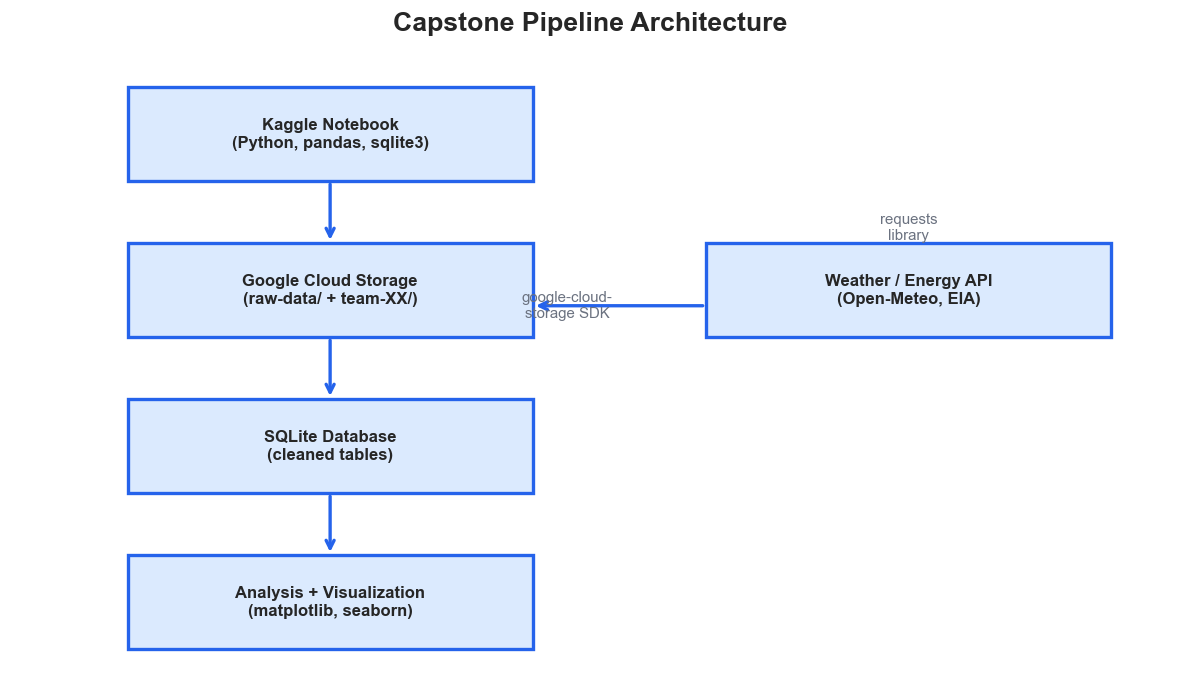

In [ ]:
# This cell shows the pipeline architecture diagram.
# (Pre-rendered for reference — you do not need to run this.)

The flow is:

1. **Kaggle notebook** authenticates to GCS using a service account key.
2. **Download raw data** from the `raw-data/` folder in the shared bucket.
3. **Clean and transform** using pandas (same skills as the midterm).
4. **Load into SQLite** for structured queries.
5. **Upload cleaned data** back to your team folder in GCS.
6. **Pull external data** from a weather or energy API.
7. **Analyze and visualize** to answer 5 pre-assigned questions.

The only new steps are 1, 2, and 5. The rest you have done before.

## The data

You are given 5 files. All of them are messy on purpose.

| File | What it is | Approximate size |
|------|-----------|------------------|
| `charging_sessions.csv` | Transaction-level session records | ~27,000 rows |
| `station_locations.csv` | Station metadata | ~21 rows |
| `vehicle_types.csv` | Vehicle and connector reference | ~42 rows |
| `grid_operators.csv` | Grid operator capacity/pricing | 5 rows |
| `energy_and_demand.db` | SQLite with demand + grid tables | ~8,400 rows |

Expect the same kinds of mess you saw in the Walmart data: duplicates, inconsistent IDs, mixed date formats, missing values encoded different ways, dollar signs in numeric fields, the works.

## A quick look at the data

Here is what daily charging sessions look like across 2025. You can see clear surge periods — spring break, the summer heat wave, football Saturdays, holiday travel.

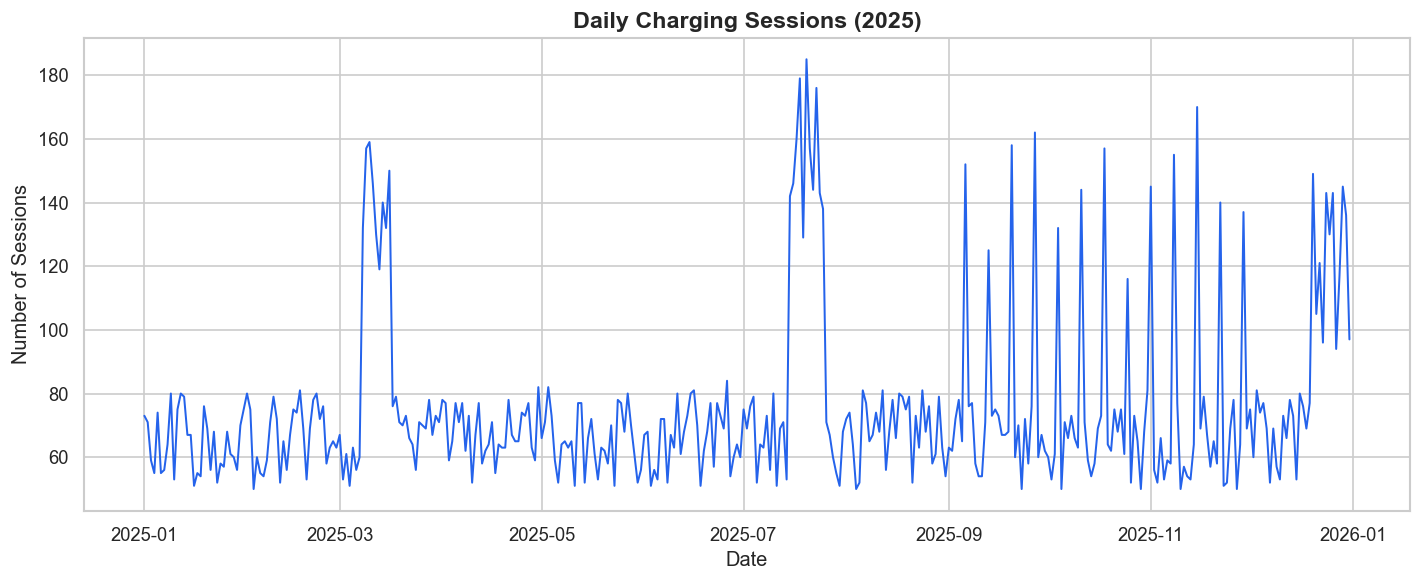

In [ ]:
# Daily session volume (pre-generated from the raw data)
import pandas as pd
import matplotlib.pyplot as plt

# This output was pre-rendered. When you run this yourself,
# you will load the CSV and generate the chart from your cleaned data.

And here is how sessions break down by station. Some stations are far busier than others.

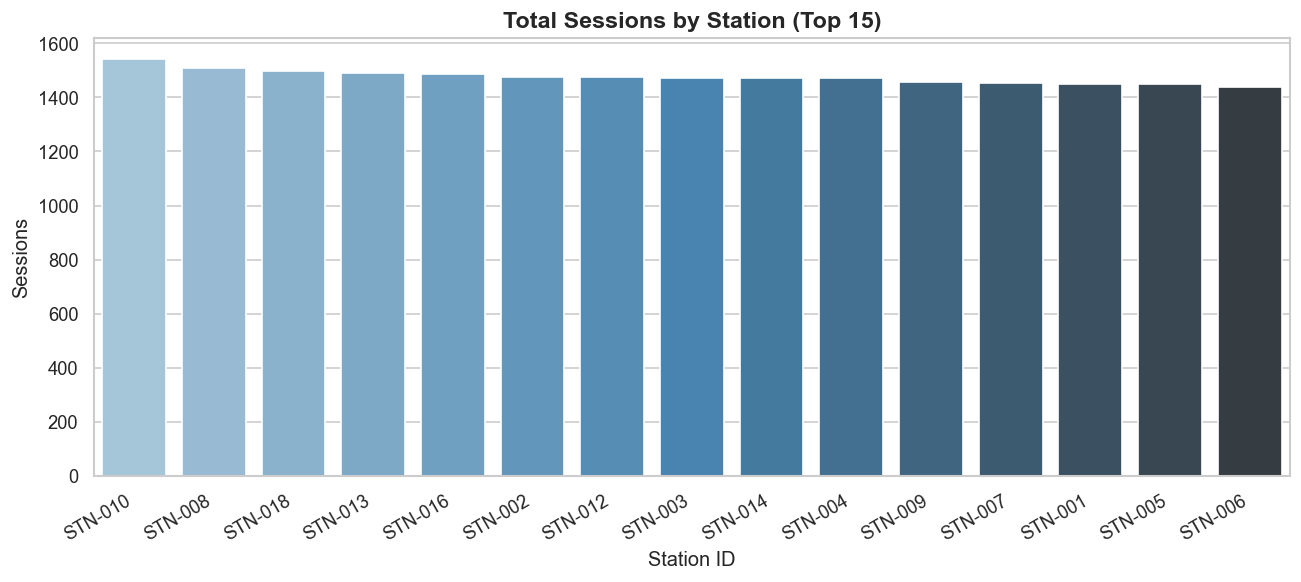

In [ ]:
# Sessions by station (pre-generated)

## The vehicle consolidation problem

Just like Pop-Tarts in the midterm appeared under four different SKUs, the same vehicle shows up under multiple IDs in this dataset. A Tesla Model 3 might be `VH-001`, `VEH#0001`, or `V_tesla_model_3`. If you do not consolidate these, your analysis will be wrong.

Here is what the raw (fragmented) vehicle ID distribution looks like:

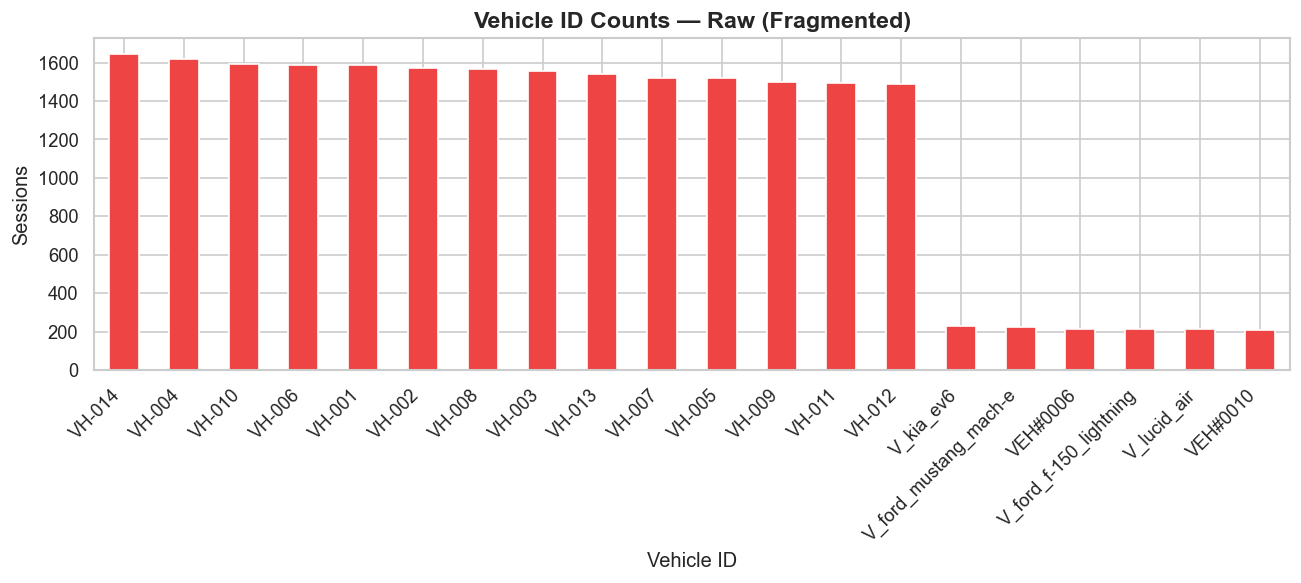

In [ ]:
# Vehicle ID fragmentation (pre-generated)

Your job is to build a mapping table and consolidate these into canonical vehicle names, then show how the picture changes.

## Teams

Form teams of 3-4 today. By end of class (or tomorrow at the latest), submit your team roster with:
- Team number (team-01 through team-20)
- Names
- UVA email addresses (these will be added to the GCP project so you can log into the Console)

Your team will receive a service account JSON key for programmatic access. One key per team.

## What to do this week

1. Read the full project brief: `DS2002_Capstone_Project_Brief.md`
2. Read the GCP walkthrough: `GCP_Console_Walkthrough.md`
3. Form your team and submit the roster
4. On Tuesday (April 1) we do the cloud onboarding lab — you will authenticate and download data from GCS for the first time

---

Questions? Ask now or on Piazza.